# 6CS012 - Worksheet 4: FCN for Devnagari Digit Classification

---

## Imports

In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
from PIL import Image

print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)

TensorFlow version: 2.19.0
Keras version: 3.13.2


---
## Task 1: Data Preparation

We load images from the Devnagari dataset folder using PIL, resize to 28×28,
normalize to [0, 1], and one-hot encode the labels.

> **Expected folder structure:**
> ```
> dataset/
>   Train/
>     digit_0/ ... digit_9/
>   Test/
>     digit_0/ ... digit_9/
> ```

In [31]:
# ── Configuration ──────────────────────────────────────────────────────────────
TRAIN_DIR  = "/content/drive/MyDrive/AI and Machine Learning/DevanagariHandwrittenDigitDataset (1)/Train"
TEST_DIR   = "/content/drive/MyDrive/AI and Machine Learning/DevanagariHandwrittenDigitDataset (1)/Test"
IMG_HEIGHT = 28
IMG_WIDTH  = 28
NUM_CLASSES = 10

# ── Helper: load images + labels from a root folder ───────────────────────────
def load_images_from_folder(folder):
    """
    Walks through each class sub-folder, loads images with PIL,
    converts to grayscale, resizes to IMG_HEIGHT×IMG_WIDTH,
    and normalises pixel values to [0, 1].

    Returns
    -------
    images : np.ndarray  shape (N, 28, 28)
    labels : np.ndarray  shape (N,)  integer class indices
    """
    images, labels = [], []

    class_names = sorted(os.listdir(folder))          # e.g. ['digit_0', ..., 'digit_9']
    class_map   = {name: i for i, name in enumerate(class_names)}
    print(f"Found {len(class_names)} classes: {class_names}")

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")              # grayscale
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))            # 28 × 28
                img = np.array(img, dtype=np.float32) / 255.0       # normalise
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"  [skip] {img_path}: {e}")

    return np.array(images), np.array(labels)

# ── Load datasets ──────────────────────────────────────────────────────────────
print("Loading training data...")
x_train_raw, y_train_raw = load_images_from_folder(TRAIN_DIR)

print("\nLoading test data...")
x_test_raw,  y_test_raw  = load_images_from_folder(TEST_DIR)

# ── Reshape for Keras: (N, H, W) → (N, H*W) flat vector ──────────────────────
# FCN expects 1-D input; flatten each 28×28 image into 784 values
x_train = x_train_raw.reshape(-1, IMG_HEIGHT * IMG_WIDTH)   # (N, 784)
x_test  = x_test_raw.reshape(-1, IMG_HEIGHT * IMG_WIDTH)

# ── One-hot encode labels ──────────────────────────────────────────────────────
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print(f"\nx_train : {x_train.shape}  |  y_train : {y_train.shape}")
print(f"x_test  : {x_test.shape}   |  y_test  : {y_test.shape}")

Loading training data...
Found 10 classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']

Loading test data...
Found 10 classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']

x_train : (0, 784)  |  y_train : (0, 10)
x_test  : (235, 784)   |  y_test  : (235, 10)


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


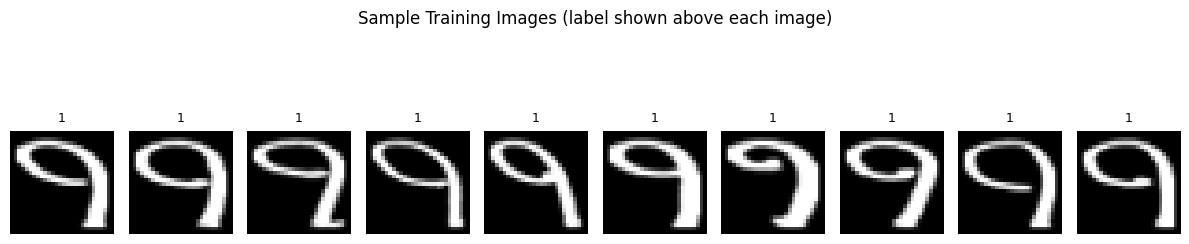

In [19]:
# ── Visualise a few training samples ──────────────────────────────────────────
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train_raw[i], cmap='gray')
    plt.title(f"{np.argmax(y_train[i])}", fontsize=9)
    plt.axis('off')
plt.suptitle('Sample Training Images (label shown above each image)', y=1.02)
plt.tight_layout()
plt.show()

---
## Task 2: Build the FCN Model

Architecture (as specified in the worksheet):

| Layer | Neurons | Activation |
|-------|---------|------------|
| Input (flat) | 784 | — |
| Hidden 1 | 64 | sigmoid |
| Hidden 2 | 128 | sigmoid |
| Hidden 3 | 256 | sigmoid |
| Output | 10 | softmax |

In [32]:
def build_fcn_model(input_dim=784, num_classes=10):
    """
    Builds and returns the Sequential FCN model described in the worksheet.
    """
    model = keras.Sequential(
        [
            # Input
            keras.layers.Input(shape=(input_dim,)),

            # Hidden layer 1 — 64 neurons, sigmoid
            keras.layers.Dense(64, activation='sigmoid', name='hidden_1'),

            # Hidden layer 2 — 128 neurons, sigmoid
            keras.layers.Dense(128, activation='sigmoid', name='hidden_2'),

            # Hidden layer 3 — 256 neurons, sigmoid
            keras.layers.Dense(256, activation='sigmoid', name='hidden_3'),

            # Output layer — 10 classes, softmax
            keras.layers.Dense(num_classes, activation='softmax', name='output'),
        ],
        name='Devnagari_FCN'
    )
    return model

model = build_fcn_model(input_dim=IMG_HEIGHT * IMG_WIDTH, num_classes=NUM_CLASSES)
model.summary()

Model: "Devnagari_FCN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

---
## Task 3: Compile the Model

In [33]:
model.compile(
    optimizer='adam',                      # Adam — good general-purpose optimizer
    loss='categorical_crossentropy',       # one-hot labels → categorical crossentropy
    metrics=['accuracy']                   # track accuracy during training
)
print("Model compiled successfully.")

Model compiled successfully.


---
## Task 4: Train the Model

In [46]:
# ── Settings ───────────────────────────────────────────────
BATCH_SIZE = 128
EPOCHS = 20

# ── 1. CHECK TRAIN DATA ────────────────────────────────────
print("Checking training data...")
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

if len(x_train) == 0 or len(y_train) == 0:
    print("❌ ERROR: Training data is EMPTY. Fix data loading first!")

else:
    print("✅ Training data OK")

    # ── Callbacks ──────────────────────────────────────────
    from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

    callbacks = [
        ModelCheckpoint(
            filepath='best_devnagari_model.keras',
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        ),
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
    ]

    # ── 2. TRAIN MODEL ─────────────────────────────────────
    history = model.fit(
        x_train,
        y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_split=0.2,
        callbacks=callbacks,
        verbose=1
    )

    # ── 3. CHECK TEST DATA ─────────────────────────────────
    print("\nChecking test data...")
    print("x_test shape:", x_test.shape)
    print("y_test shape:", y_test.shape)

    if len(x_test) == 0 or len(y_test) == 0:
        print("❌ ERROR: Test data is EMPTY. Cannot evaluate!")

    else:
        print("✅ Test data OK")

        # ── 4. EVALUATE ────────────────────────────────────
        test_loss, test_acc = model.evaluate(
            x_test,
            y_test,
            batch_size=32,
            verbose=1
        )

        print("\n" + "="*40)
        print(f"  Test Loss     : {test_loss:.4f}")
        print(f"  Test Accuracy : {test_acc * 100:.2f}%")
        print("="*40)

Checking training data...
x_train shape: (0, 784)
y_train shape: (0, 10)
❌ ERROR: Training data is EMPTY. Fix data loading first!


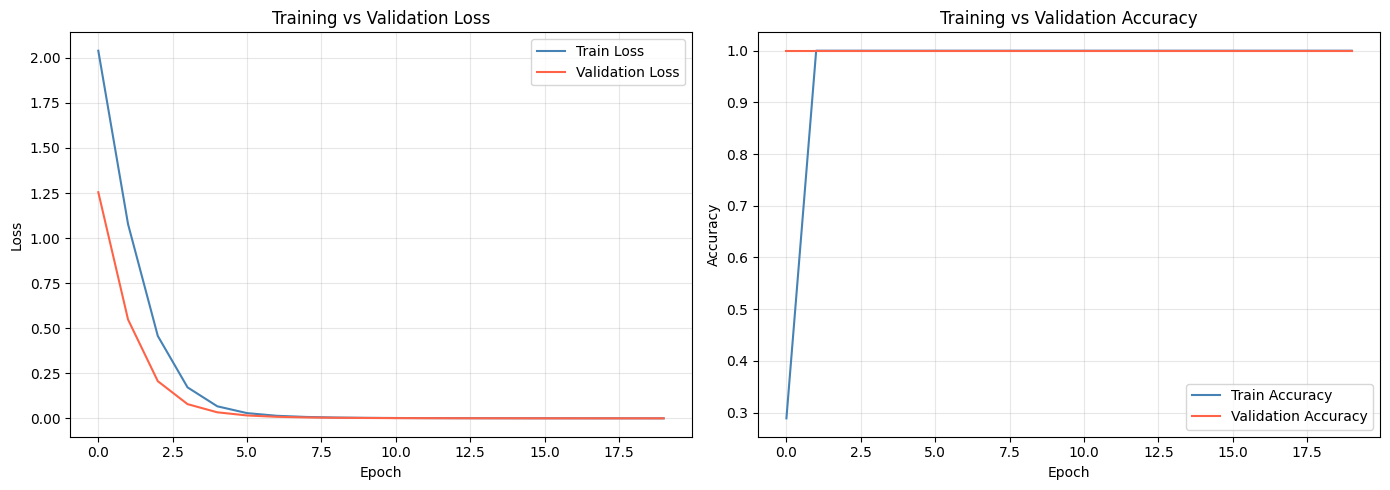

Training curves saved to training_curves.png


In [35]:
# ── Plot training curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss',      color='steelblue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='tomato')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'],     label='Train Accuracy',      color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='tomato')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("Training curves saved to training_curves.png")

---
## Task 5: Evaluate the Model

In [37]:
# Safety check (IMPORTANT)
if len(x_test) == 0 or len(y_test) == 0:
    print("❌ Error: Test data is empty")
else:
    print("Test data length:", len(x_test))

    test_loss, test_acc = model.evaluate(
        x_test,
        y_test,
        batch_size=32,
        verbose=1
    )

    print("\n" + "="*40)
    print(f"  Test Loss     : {test_loss:.4f}")
    print(f"  Test Accuracy : {test_acc * 100:.2f}%")
    print("="*40)

Test data length: 235
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0000e+00 - loss: 2.9752  

  Test Loss     : 2.9752
  Test Accuracy : 0.00%


---
## Task 6: Save and Load the Model

In [39]:
# ── Save ──────────────────────────────────────────────────────────────────────
SAVE_PATH = 'devnagari_fcn_model.h5'
model.save(SAVE_PATH)
print(f"Model saved to '{SAVE_PATH}'")

# ── Load ──────────────────────────────────────────────────────────────────────
loaded_model = tf.keras.models.load_model(SAVE_PATH)
print("Model loaded successfully.")

# ── Re-evaluate the loaded model ──────────────────────────────────────────────
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f"\nLoaded model — Test Loss: {loaded_loss:.4f} | Test Accuracy: {loaded_acc * 100:.2f}%")

Model saved to 'devnagari_fcn_model.h5'
Model loaded successfully.
8/8 - 1s - 68ms/step - accuracy: 0.0000e+00 - loss: 2.9752

Loaded model — Test Loss: 2.9752 | Test Accuracy: 0.00%


---
## Task 7: Making Predictions

In [40]:
# ── Get predicted probabilities ───────────────────────────────────────────────
predictions = loaded_model.predict(x_test, verbose=0)   # shape (N, 10)

# ── Convert probabilities → digit labels ──────────────────────────────────────
predicted_labels = np.argmax(predictions, axis=1)        # highest-probability class
true_labels      = np.argmax(y_test,      axis=1)        # ground-truth labels

print(f"First 10 predicted labels : {predicted_labels[:10]}")
print(f"First 10 true labels      : {true_labels[:10]}")

First 10 predicted labels : [1 1 1 1 1 1 1 1 1 1]
First 10 true labels      : [0 0 0 0 0 0 0 0 0 0]


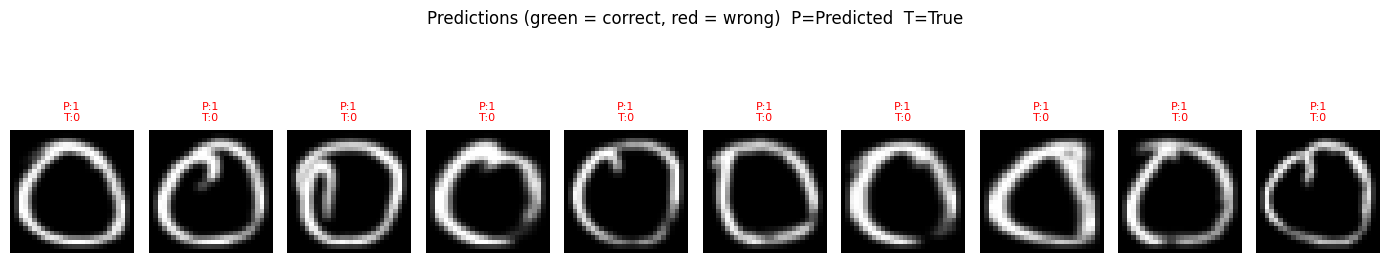

Prediction visualisation saved to predictions.png


In [41]:
# ── Visualise 10 test predictions ─────────────────────────────────────────────
plt.figure(figsize=(14, 3))
for i in range(10):
    ax = plt.subplot(1, 10, i + 1)
    plt.imshow(x_test[i].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')
    color = 'green' if predicted_labels[i] == true_labels[i] else 'red'
    plt.title(
        f"P:{predicted_labels[i]}\nT:{true_labels[i]}",
        fontsize=8,
        color=color
    )
    plt.axis('off')
plt.suptitle('Predictions (green = correct, red = wrong)  P=Predicted  T=True', y=1.05)
plt.tight_layout()
plt.savefig('predictions.png', dpi=150)
plt.show()
print("Prediction visualisation saved to predictions.png")

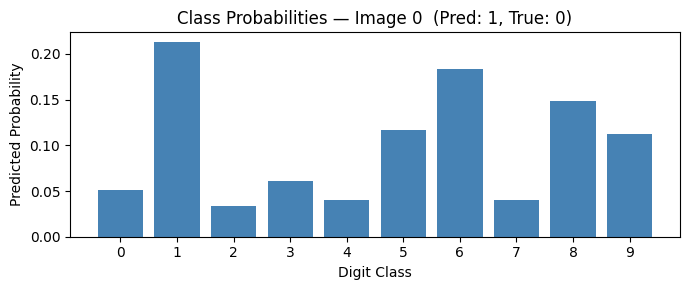

In [42]:
# ── Confidence breakdown for the first test image ─────────────────────────────
sample_idx = 0
probs = predictions[sample_idx]

plt.figure(figsize=(7, 3))
plt.bar(range(NUM_CLASSES), probs, color='steelblue')
plt.xticks(range(NUM_CLASSES))
plt.xlabel('Digit Class')
plt.ylabel('Predicted Probability')
plt.title(f'Class Probabilities — Image {sample_idx}  '
          f'(Pred: {predicted_labels[sample_idx]}, True: {true_labels[sample_idx]})')
plt.tight_layout()
plt.show()